# Olivia Weihmuller
<h1 align="center">TS2: Modelizando un ADC</h1>

En este trabajo práctico se simula el proceso de conversión analógica-digital (A/D) sobre una señal senoidal continua contaminada por ruido analógico. Para sumarle a la tarea previa, en esta experiencia se incorpora el muestreo temporal discreto a una frecuencia de $f_S = 1000\text{ Hz}$ junto con el bloque de cuantización uniforme de $B$ bits sobre un rango analógico de plena escala de $V_{FS} = 2V_F = 4\text{ V}$ ($\pm 2\text{ V}$). La señal analógica de entrada $s_R[n] = s[n] + n[n]$ se compone de una senoidal pura de potencia unitaria ($P_s = 1\text{ W}$) y un ruido analógico aditivo $n[n]$, caracterizado como un proceso estocástico incorrelado (blanco) y Gaussiano. La potencia de este ruido externo se define en términos relativos como $P_n = k_n \cdot P_q$, tomando como referencia la potencia teórica del ruido de cuantización propio del ADC, dada por $P_q = \frac{q^2}{12}$ (con $q = \frac{V_{FS}}{2^B}$). El objetivo principal de la experiencia es analizar el impacto conjunto de la resolución del convertidor ($B$) y el nivel de interferencia analógica ($k_n$) sobre la relación señal-ruido (SNR) y el número efectivo de bits a la salida del sistema.

Para ver la potencia (varianza) total del ruido a la salida del ADC, se deben sumar las potencias de las dos fuentes de ruido, asumiendo que son independientes entre sí:$$P_{\text{total}} = P_q + P_n$$Pero habíamos definido que $P_n = k_n \cdot P_q$ y $P_q = \frac{q^2}{12} = \frac{(V_{\text{FS}} / 2^B)^2}{12}$, con $V_{\text{FS}} = 2 V_F$ . Reemplazando:$$P_{\text{total}} = P_n + P_q = k_n P_q + P_q = (k_n + 1) P_q = (k_n + 1) \frac{q^2}{12}$$Si esto lo llevamos al SNR (recordando que la señal está normalizada, $P_s = 1$):$$\text{SNR}_{\text{lineal}} = \frac{P_s}{P_{\text{total}}} = \frac{1}{(k_n + 1) \frac{q^2}{12}} = \frac{12 \cdot 2^{2B}}{V_{\text{FS}}^2 (k_n + 1)}$$Y con $V_{\text{FS}} = 4\text{ V}$ (porque $V_F = 2\text{ V}$), en decibeles queda:$$\text{SNR}_{\text{dB}} \approx -1{,}25\text{ dB} + 6{,}02 \cdot B - 10\log_{10}(k_n + 1)$$Se observa que cada bit de resolución adicional aporta $6{,}02\text{ dB}$ de mejora en el SNR, es decir, reduce a la mitad el paso de cuantización $q$ y, por lo tanto, la potencia de su ruido asociado.Efecto de variar $k_n$ (relación entre ruido analógico y ruido de cuantización):$k_n = 0{,}1$: El ruido analógico es 10 veces menor que el de cuantización. Su impacto es mínimo, ya que $P_{\text{total}} = 1{,}1 P_q$ (penalización de solo $-10\log_{10}(1{,}1) \approx -0{,}41\text{ dB}$). En este régimen, aumentar $B$ sigue mejorando el SNR casi al ritmo ideal de $6{,}02\text{ dB/bit}$, porque el sistema está limitado por la cuantización.$k_n = 1$: Ambas potencias son iguales, $P_{\text{total}} = 2 P_q$, lo que hace caer el SNR $3{,}01\text{ dB} (-10log(2) = -3,01 dB)$ respecto del caso ideal ($k_n \to 0$). Como cada bit vale $\approx 6{,}02\text{ dB}$, una caída de $3{,}01\text{ dB}$ equivale a perder la mitad del aporte de un bit ($\frac{3{,}01}{6{,}02} \approx 0{,}5$). En otras palabras, sumar un ruido externo de igual potencia que el de cuantización es como si el ADC tuviera medio bit menos de resolución efectiva. $k_n = 10$: El ruido analógico es 10 veces mayor que el de cuantización, $P_{\text{total}} = 11 P_q$, costandole $-10\log_{10}(11) \approx -10{,}41\text{ dB}$. Acá el sistema está limitado por el canal analógico: aunque se aumente $B$ (y por lo tanto se reduzca $P_q$ hasta hacerse despreciable), el SNR total queda "pegado" al valor que impone $P_n$, porque ya no es el término dominante en la suma. Aumentar bits deja de traer mejoras significativas más allá de cierto punto.

In [31]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

#%%
fs = 1000       # Hz
N = 1000        # Cantidad de muestras
Ps = 1          # W, potencia de la señal
VFS = 2         # V, rango del ADC +- 2V
f0 = fs / N     # Frecuencia fundamental (1 Hz)

#%%

def paso_cuantizacion(B, VFS):
    q = (2 * VFS) / (2**B)
    return q

def cuantizacion(x, q, VFS):
    x_recortada = np.clip(x, -VFS, VFS) 
    x_cuantizada = q * np.round(x_recortada / q)
    return x_cuantizada

def espectro_db(x, N, eps=1e-15):
    fft_x = np.fft.fft(x)
    pot_por_bin = (np.abs(fft_x)**2) / (N**2)
    return 10 * np.log10(pot_por_bin[:N//2] + eps)

def generar_senoidal_con_snr(Ps, f0, N, fs, B, VFS, kn):
    nn = np.arange(N)
    tt = nn / fs
    
    amp = np.sqrt(2 * Ps)   # despejado de P = A^2 / 2
    senal = amp * np.sin(2 * np.pi * f0 * tt)
    
    q = paso_cuantizacion(B, VFS)
    Pq = (q**2) / 12        # potencia del ruido de cuantización
    Pn = kn * Pq            # potencia del ruido analógico
    
    ruido = rng.normal(0, np.sqrt(Pn), N)
    x = senal + ruido
    
    return tt, senal, x, Pn, Pq, q

def simular(B, kn):
    # 1. Generar señal con ruido analógico y cuantizar
    tt, senal, senal_ruido_analogico, Pn, Pq, q = generar_senoidal_con_snr(
        Ps=Ps, f0=f0, N=N, fs=fs, B=B, VFS=VFS, kn=kn
    )
    
    senal_ruido_cuantizada = cuantizacion(x=senal_ruido_analogico, q=q, VFS=VFS)
    error_cuant = senal_ruido_cuantizada - senal_ruido_analogico

    # 2. Imprimir potencias medidas y teóricas
    print(f"=== RESULTADOS PARA B={B} bits, kn={kn} ===")
    print("Potencia señal (medida):", np.var(senal), "(teórica:", Ps, ")")
    print("Potencia ruido analógico Pn (medida):", np.var(senal_ruido_analogico - senal), "(teórica Pn:", Pn, ")")
    print("Potencia error cuantización Pq (medida):", np.var(error_cuant), "(teórica Pq:", Pq, ")")
    print("-" * 50)

    # 3. Gráfico en el tiempo
    plt.figure(figsize=(10, 4))
    plt.plot(tt, senal_ruido_analogico, color='red', linestyle=':', label='s + n (entrada al ADC)', zorder=2)
    plt.plot(tt, senal_ruido_cuantizada, color='lightseagreen', linestyle='-.', label='Salida ADC (cuantizada)', zorder=1)
    plt.plot(tt, senal, color='blue', linestyle='-', label='Señal analógica (s)', zorder=3)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud [V]')
    plt.title(f'Dominio del tiempo (B={B} bits, kn={kn})')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 4. Gráfico en frecuencia (Espectro + Pisos teóricos)
    freqs = np.fft.fftfreq(N, d=1/fs)[:N//2]
    db_cuant = espectro_db(senal_ruido_cuantizada, N)
    
    piso_analogico_db = 10 * np.log10(Pn / N)
    piso_digital_db   = 10 * np.log10((Pn + Pq) / N)
    ylim_min = piso_digital_db - 25
    
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, db_cuant, label='Salida ADC (Sq)')
    plt.axhline(piso_analogico_db, color='green', linestyle='--', label=f'Piso analógico teórico ({piso_analogico_db:.1f} dB)')
    plt.axhline(piso_digital_db, color='red', linestyle='--', label=f'Piso digital teórico ({piso_digital_db:.1f} dB)')
    plt.ylim(ylim_min, 0)
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Densidad de Potencia [dB]')
    plt.title(f'Espectro - B={B} bits, kn={kn}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5. Histograma del error de cuantización
    plt.figure(figsize=(7, 4))
    plt.hist(error_cuant, bins=10, alpha=0.7)
    plt.xlabel("Error de cuantización [V]")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma del error de cuantización (B={B} bits, kn={kn})")
    plt.tight_layout()
    plt.show()

Para realizar todos los graficos pedidos generalize en funciones para poder hacer que quede mas prolijo el codigo y para simplifcarlo. 

=== RESULTADOS PARA B=4 bits, kn=1 ===
Potencia señal (medida): 1.0000000000000002 (teórica: 1 )
Potencia ruido analógico Pn (medida): 0.005569998028755274 (teórica Pn: 0.005208333333333333 )
Potencia error cuantización Pq (medida): 0.005143769263878514 (teórica Pq: 0.005208333333333333 )
--------------------------------------------------


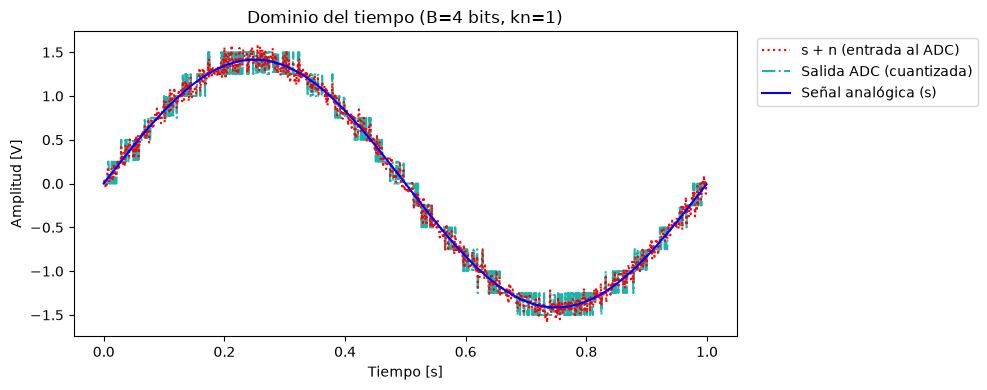

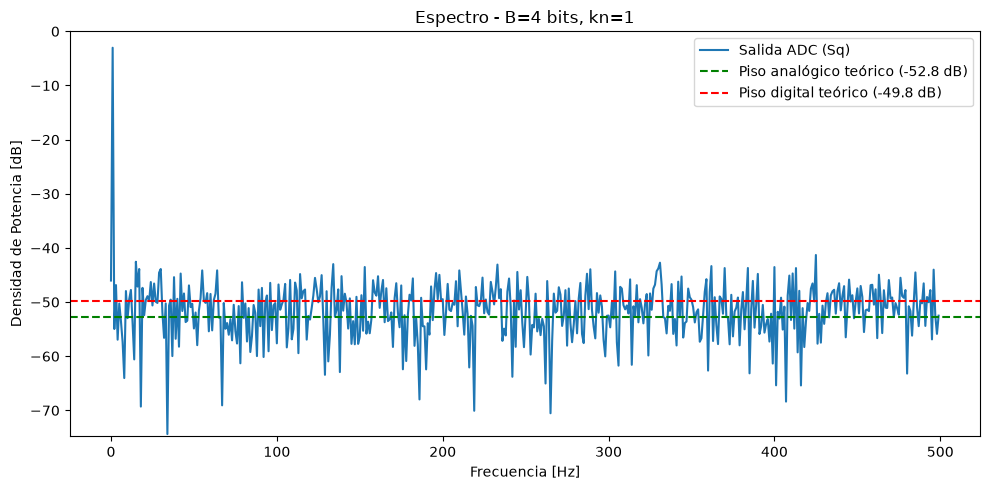

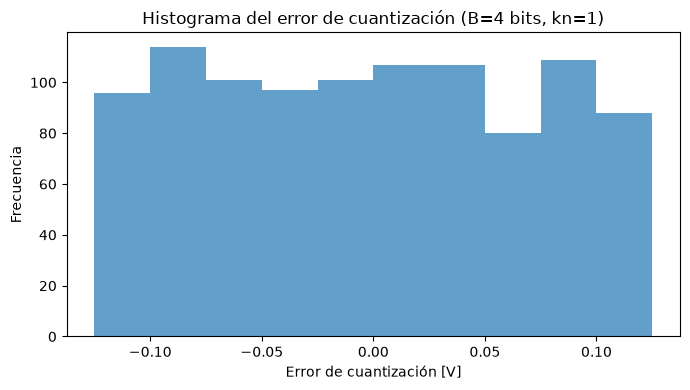

=== RESULTADOS PARA B=4 bits, kn=0.1 ===
Potencia señal (medida): 1.0000000000000002 (teórica: 1 )
Potencia ruido analógico Pn (medida): 0.0005530577653629248 (teórica Pn: 0.0005208333333333333 )
Potencia error cuantización Pq (medida): 0.005848466567641465 (teórica Pq: 0.005208333333333333 )
--------------------------------------------------


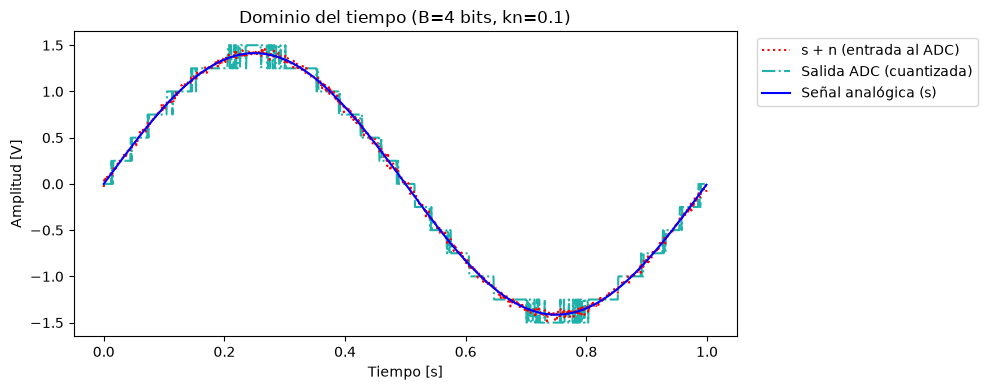

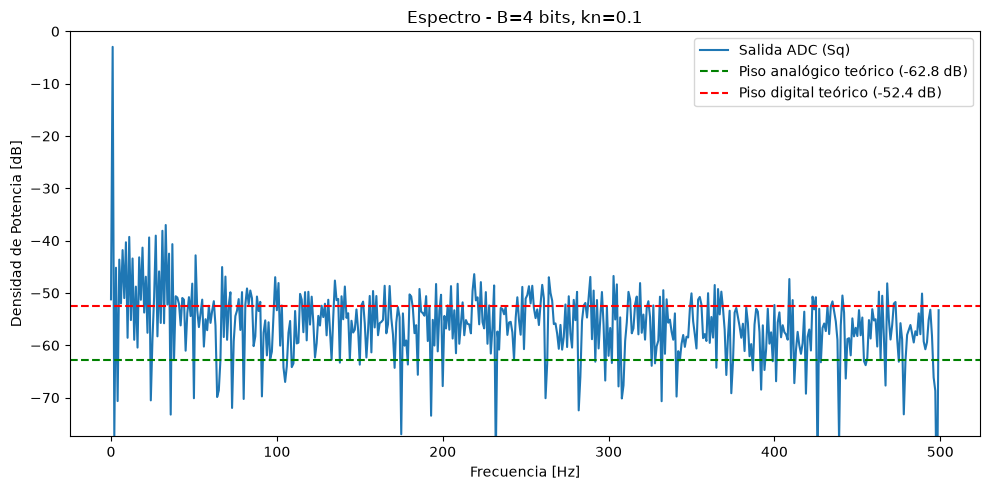

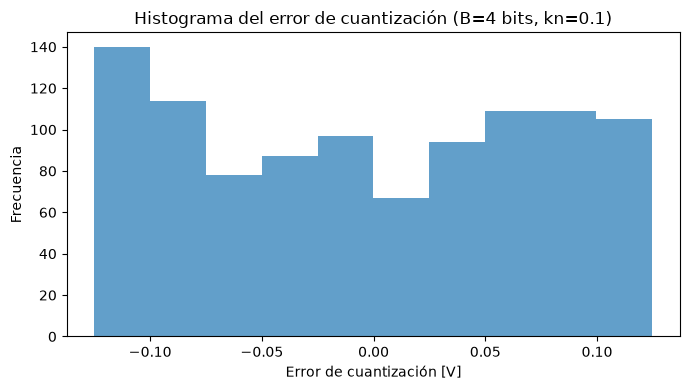

=== RESULTADOS PARA B=4 bits, kn=10 ===
Potencia señal (medida): 1.0000000000000002 (teórica: 1 )
Potencia ruido analógico Pn (medida): 0.04947537071022928 (teórica Pn: 0.05208333333333333 )
Potencia error cuantización Pq (medida): 0.005274387703266617 (teórica Pq: 0.005208333333333333 )
--------------------------------------------------


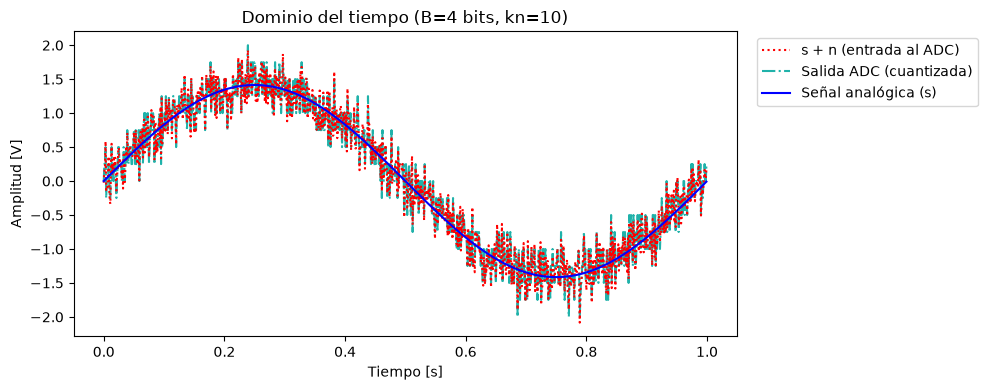

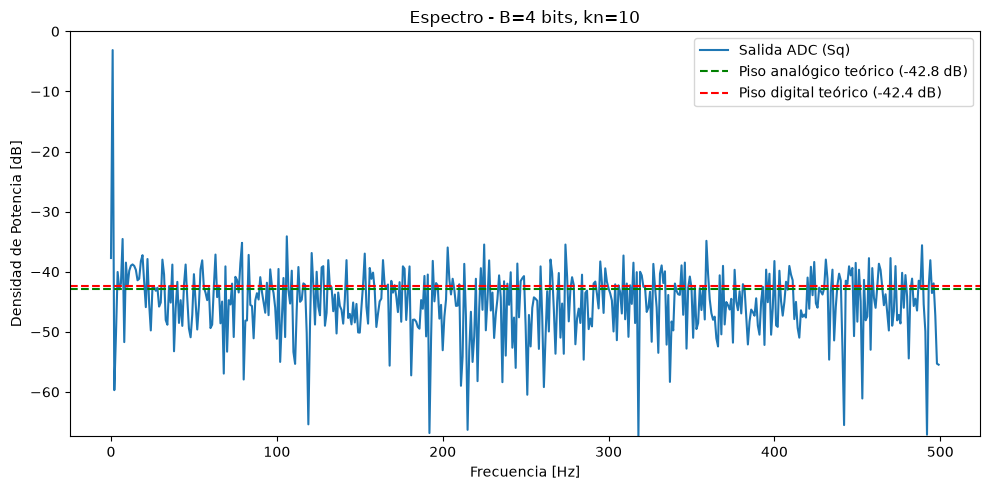

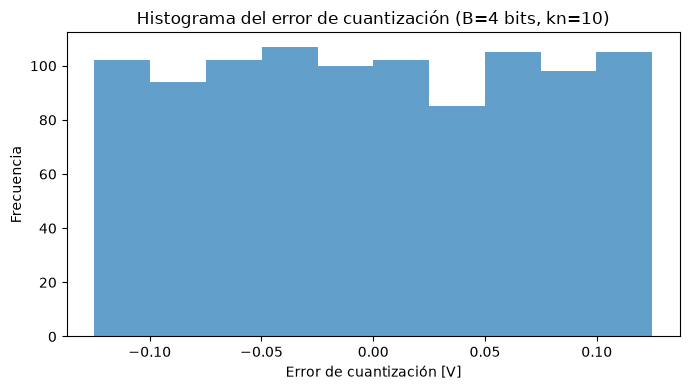

In [32]:
#%%

# a)
simular(B=4, kn=1)

# b) y bonus
simular(B=4, kn=0.1)
simular(B=4, kn=10)


Para la resolución de $B = 4$ bits, el impacto de $k_n$ se evidencia en el dominio de la frecuencia como en el tiempo: 
Análisis Espectral (Frecuencia): Caso $k_n = 0,1$ (figura Espectro - B=4, kn=0.1): El sistema está limitado por cuantización. Como $P_n = 0,1 P_q$, la potencia del ruido del ADC es 10 veces mayor que la del ruido analógico de entrada. En el gráfico, esto se traduce en que el piso de ruido digital se ubica exactamente $10\text{ dB}$ por encima del piso analógico previo a la conversión. Caso $k_n = 1$ (figura Espectro - B=4, kn=1): Ambos ruidos aportan exactamente la misma potencia ($P_n = P_q$). La suma de dos potencias iguales duplica la potencia de ruido total ($P_{\text{total}} = 2 P_q$), lo que genera un incremento exacto de $3\text{ dB}$ ($10 \log_{10}(2) \approx 3,01\text{ dB}$) en el piso de ruido resultante respecto al nivel analógico de entrada (de $-52,8\text{ dB}$ a $-49,8\text{ dB}$), tal como pse discutio previamente. Caso $k_n = 10$ (figura Espectro - B=4, kn=10): El ruido analógico de entrada es 10 veces más potente que el error propio del ADC ($P_n = 10 P_q$). Al ser $P_{\text{total}} = 11 P_q$, el aporte del cuantizador representa apenas un incremento de $0,41\text{ dB}$ ($10 \log_{10}(11/10)$), haciendo que los pisos analógico y digital resulten prácticamente superpuestos e indistinguibles a simple vista.
Análisis Temporal: Cambiar el valor de $k_n$ cambia por completo cómo se ve la señal en el tiempo. Cuando $k_n = 0,1$, el ruido de entrada es tan chico que casi no se nota, por lo que la señal digitalizada muestra con claridad la típica forma de "escalera" de los 16 niveles del ADC de 4 bits. En cambio, cuando subimos $k_n$ a $10$, la señal se vuelve súper ruidosa y desprolija. Esto pasa porque el ruido analógico de afuera ($P_n$) pasa a ser 10 veces más fuerte que el ruido propio de cuantización ($P_q$). Esas sacudidas de voltaje son mucho más grandes que el tamaño del escalón ($q$), tapando la forma escalonada del convertidor.

=== RESULTADOS PARA B=8 bits, kn=0.1 ===
Potencia señal (medida): 1.0000000000000002 (teórica: 1 )
Potencia ruido analógico Pn (medida): 2.101609733262573e-06 (teórica Pn: 2.0345052083333333e-06 )
Potencia error cuantización Pq (medida): 2.050621628008923e-05 (teórica Pq: 2.0345052083333332e-05 )
--------------------------------------------------


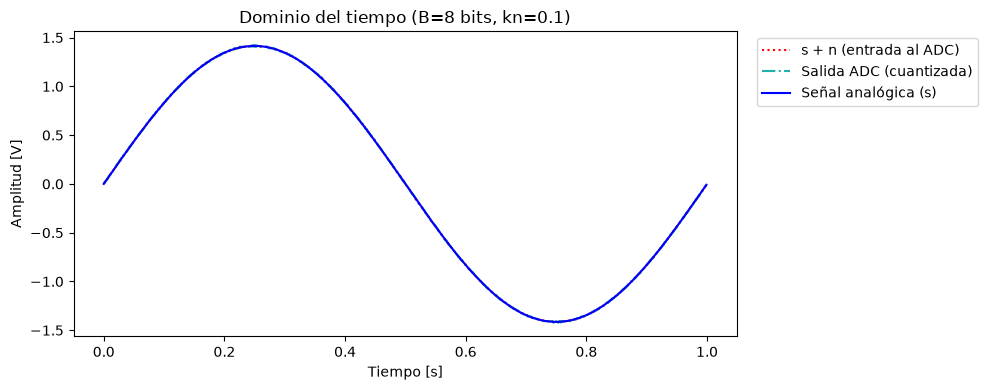

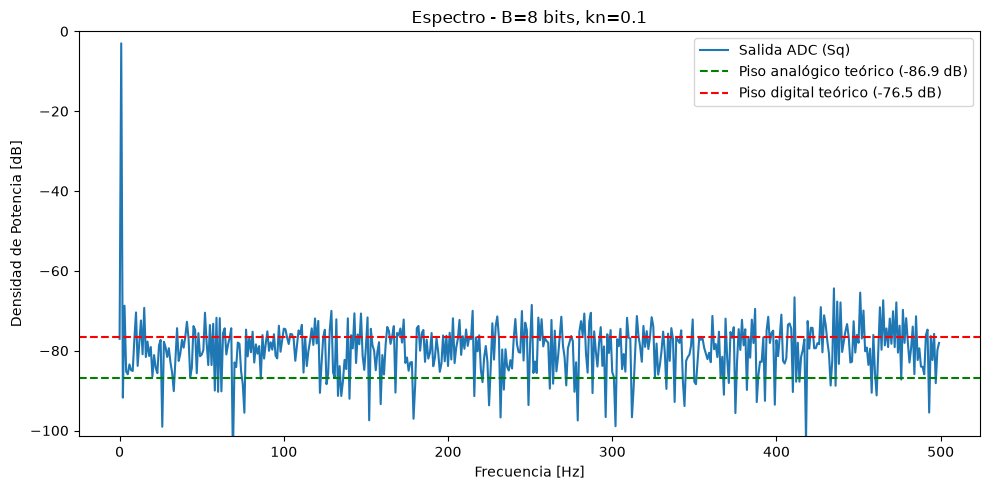

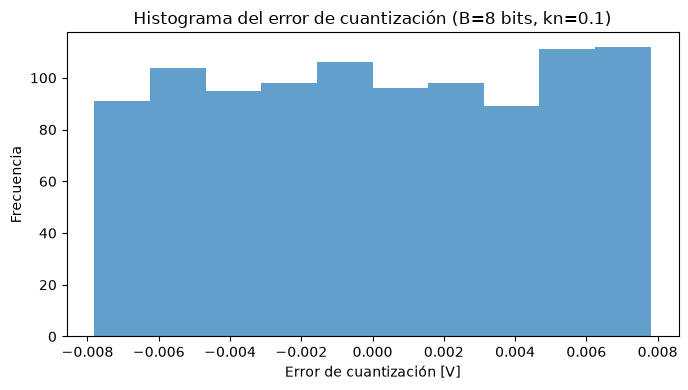

=== RESULTADOS PARA B=8 bits, kn=1 ===
Potencia señal (medida): 1.0000000000000002 (teórica: 1 )
Potencia ruido analógico Pn (medida): 2.1636200951218292e-05 (teórica Pn: 2.0345052083333332e-05 )
Potencia error cuantización Pq (medida): 2.0967174138744397e-05 (teórica Pq: 2.0345052083333332e-05 )
--------------------------------------------------


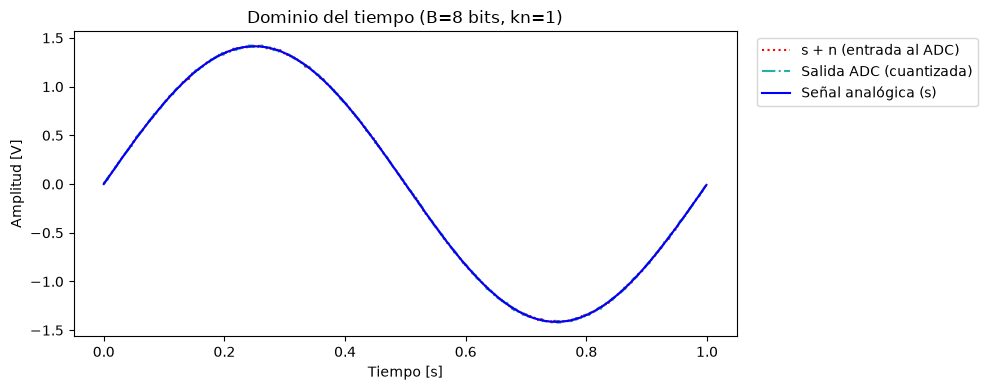

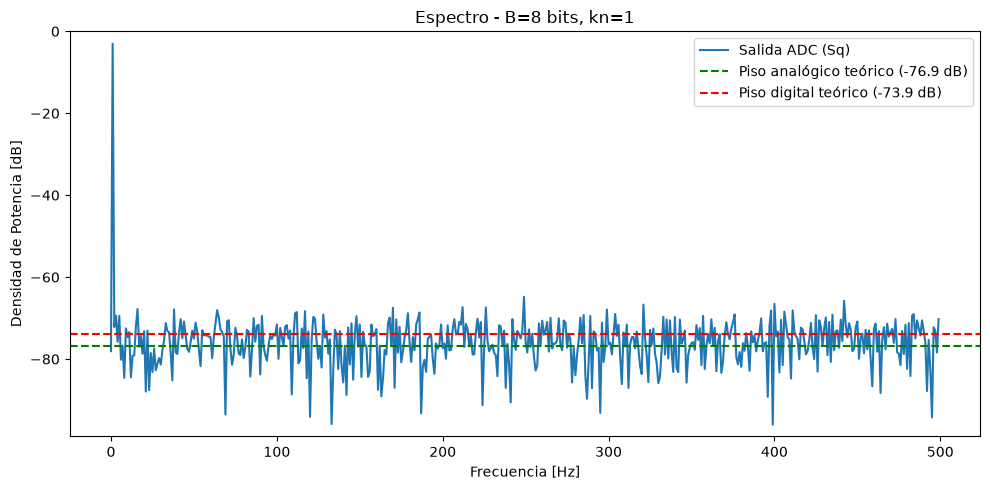

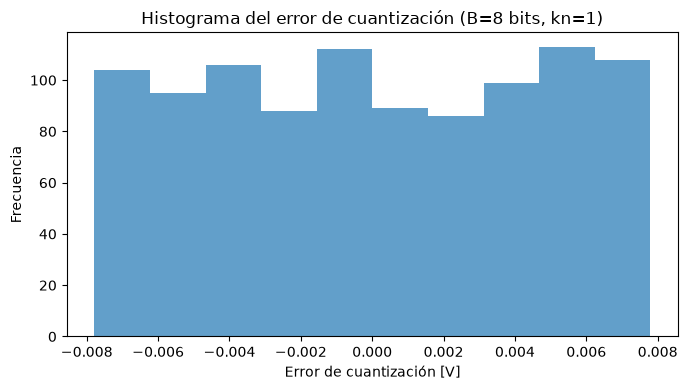

=== RESULTADOS PARA B=8 bits, kn=10 ===
Potencia señal (medida): 1.0000000000000002 (teórica: 1 )
Potencia ruido analógico Pn (medida): 0.0002003466312200835 (teórica Pn: 0.00020345052083333332 )
Potencia error cuantización Pq (medida): 2.0653834473272082e-05 (teórica Pq: 2.0345052083333332e-05 )
--------------------------------------------------


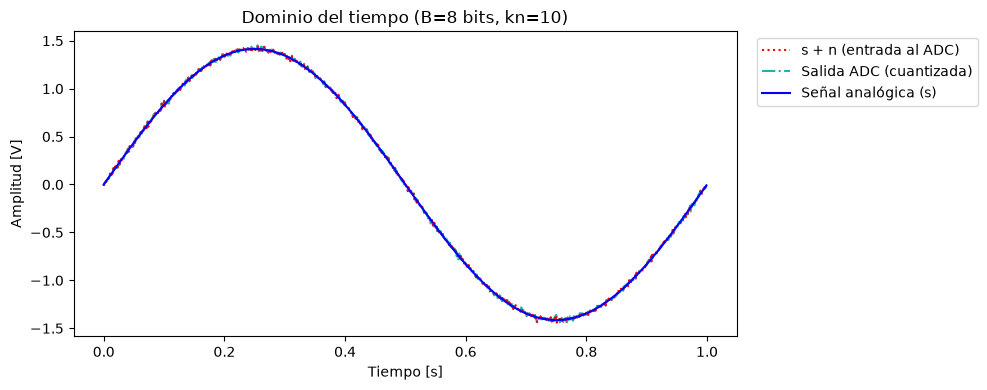

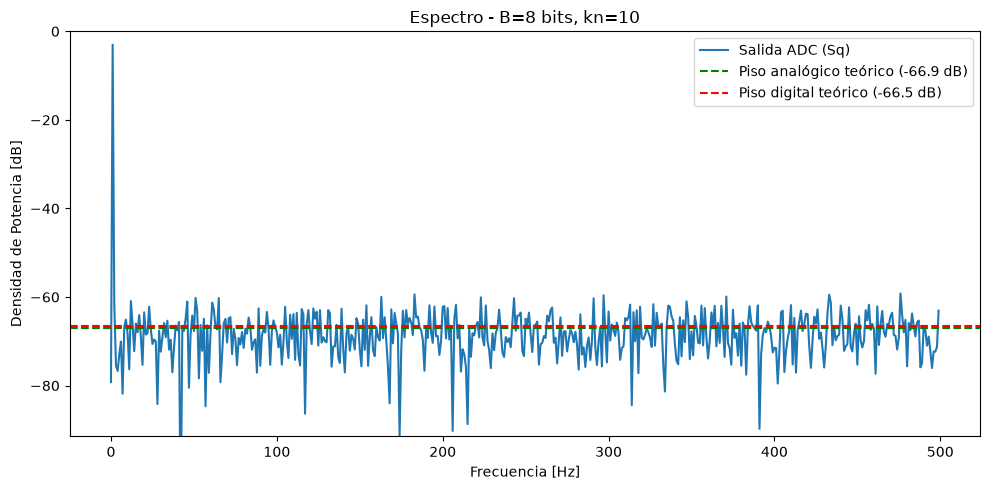

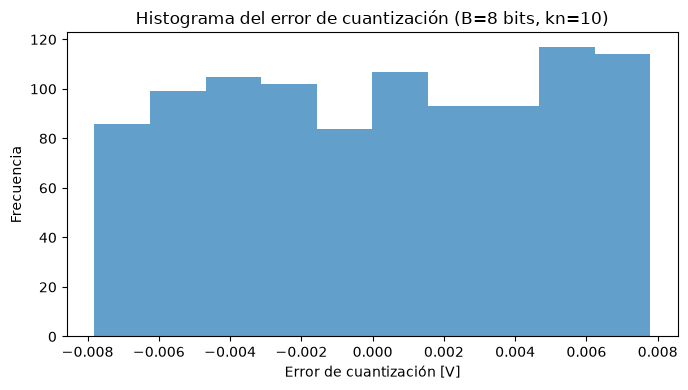

In [33]:
simular(B=8, kn=0.1)
simular(B=8, kn=1)
simular(B=8, kn=10)

Al aumentar la resolución a $B = 8$ bits ($256$ niveles de cuantización), el paso de cuantización se reduce a $q \approx 15.6\text{ mV}$. Esto genera cambios muy claros respecto al escenario de 4 bits: 
Dominio del tiempo:
Para $k_n = 0.1$, los escalones de cuantización son prácticamente imperceptibles y el ruido externo es casi nulo, por lo que la señal digitalizada se observa como una senoidal suave y limpia. Para $k_n = 1$, la señal conserva esa apariencia continua respecto a los niveles del ADC, pero empieza a presentar una especie de "temblor" debido a que el ruido analógico aporta la misma potencia que el redondeo. Finalmente, para $k_n = 10$, la señal pierde su suavidad y se vuelve claramente ruidosa, ya que el ruido analógico de entrada ($P_n = 10 P_q$) supera  el tamaño del escalón $q$.
Dominio de la frecuencia (Espectro):
Al sumar 4 bits de resolución respecto al caso anterior, la potencia de cuantización $P_q$ disminuye un factor de $256$, lo que desplaza todo el piso de ruido espectral aproximadamente $24\text{ dB}$ hacia abajo. Las distancias relativas entre los pisos de ruido analógico y digital se comportan de la misma manera que en 4 bits: en $k_n = 0.1$ el piso digital se ubica $10\text{ dB}$ por encima del analógico; en $k_n = 1$ la suma de potencias iguales eleva el piso en $3\text{ dB}$; y en $k_n = 10$ el peso del ruido analógico hace que ambos pisos queden prácticamente superpuestos.

=== RESULTADOS PARA B=16 bits, kn=0.1 ===
Potencia señal (medida): 1.0000000000000002 (teórica: 1 )
Potencia ruido analógico Pn (medida): 3.030908606180203e-11 (teórica Pn: 3.104408582051595e-11 )
Potencia error cuantización Pq (medida): 3.3338189843435237e-10 (teórica Pq: 3.104408582051595e-10 )
--------------------------------------------------


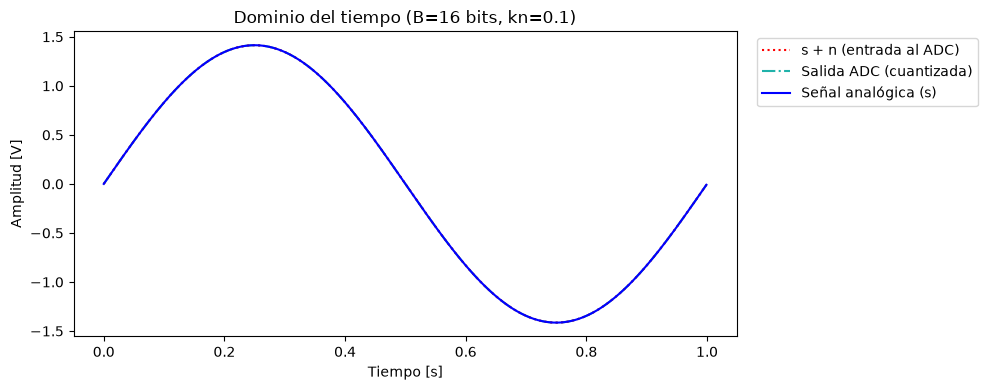

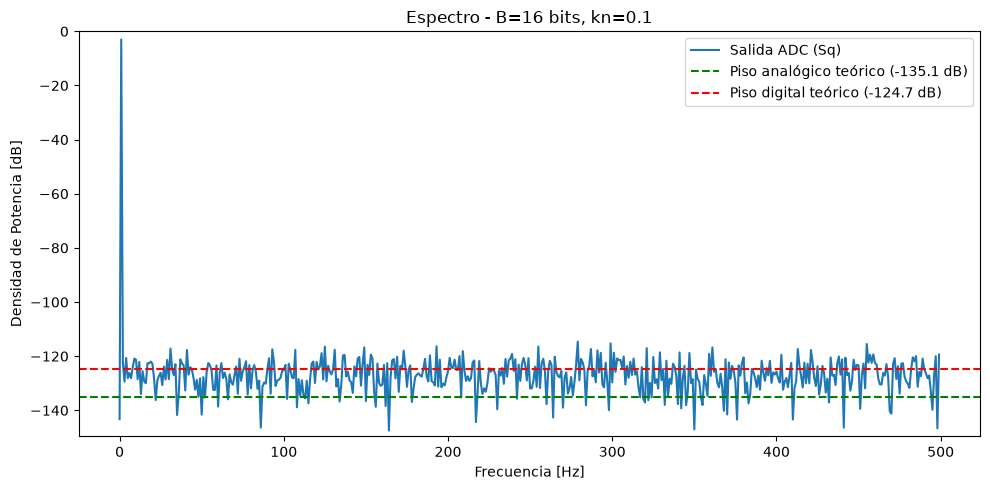

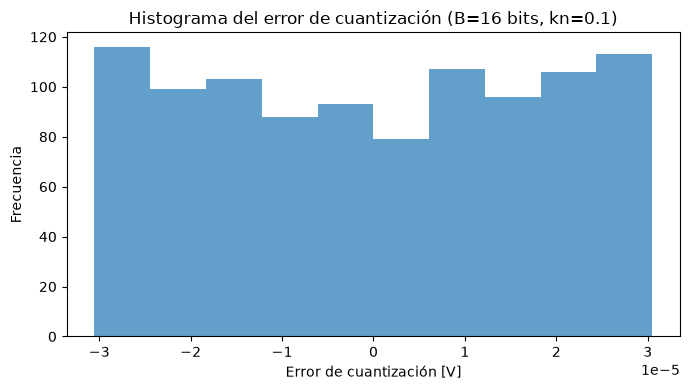

=== RESULTADOS PARA B=16 bits, kn=1 ===
Potencia señal (medida): 1.0000000000000002 (teórica: 1 )
Potencia ruido analógico Pn (medida): 3.098854604355149e-10 (teórica Pn: 3.104408582051595e-10 )
Potencia error cuantización Pq (medida): 3.111291689749075e-10 (teórica Pq: 3.104408582051595e-10 )
--------------------------------------------------


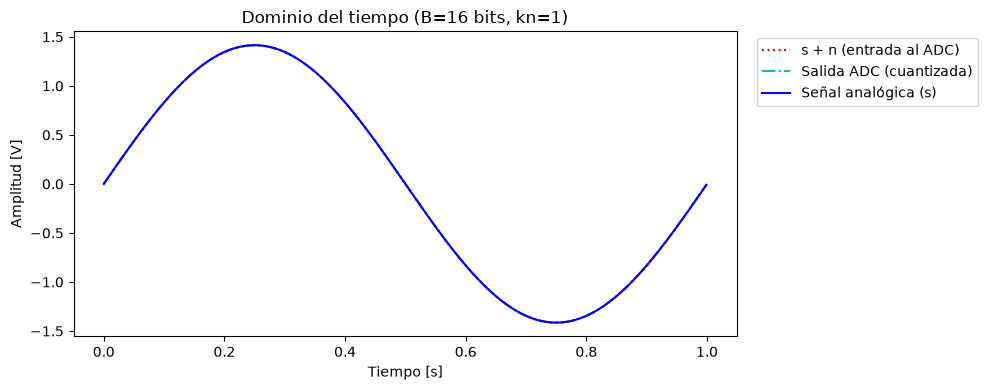

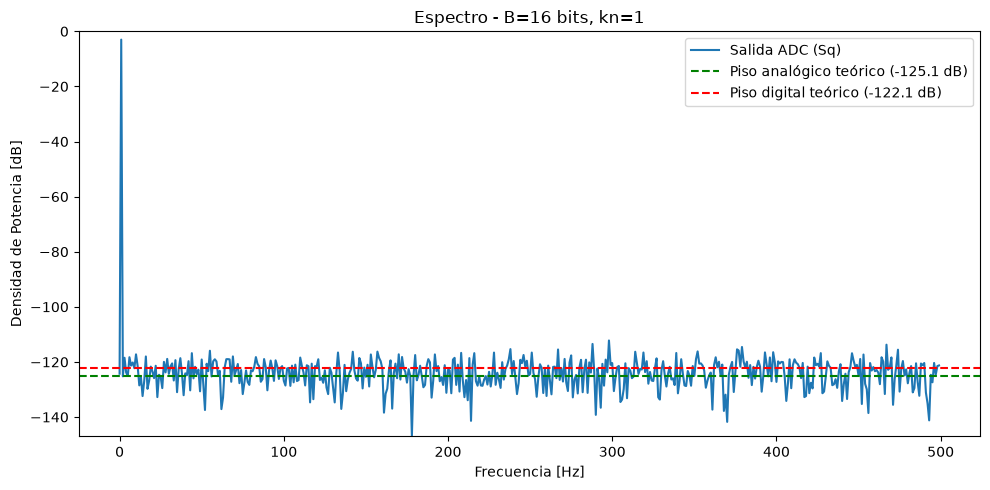

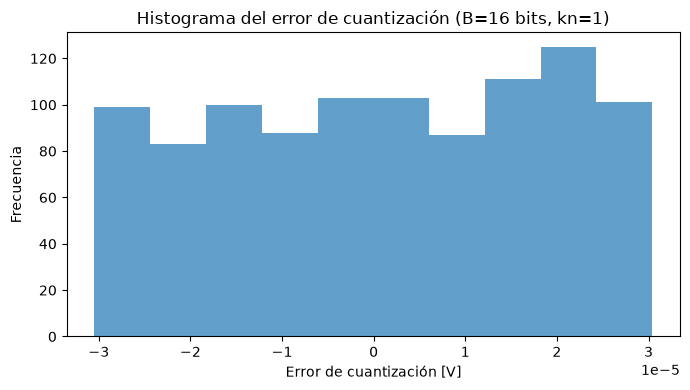

=== RESULTADOS PARA B=16 bits, kn=10 ===
Potencia señal (medida): 1.0000000000000002 (teórica: 1 )
Potencia ruido analógico Pn (medida): 3.131075674336334e-09 (teórica Pn: 3.1044085820515948e-09 )
Potencia error cuantización Pq (medida): 3.0881581347545546e-10 (teórica Pq: 3.104408582051595e-10 )
--------------------------------------------------


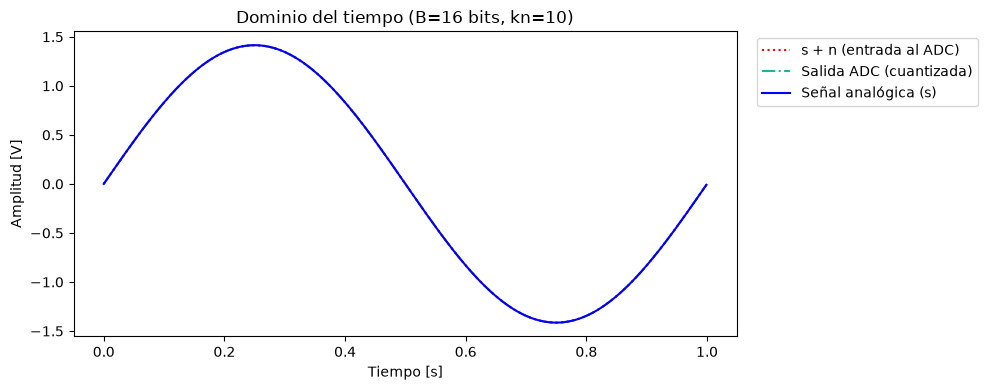

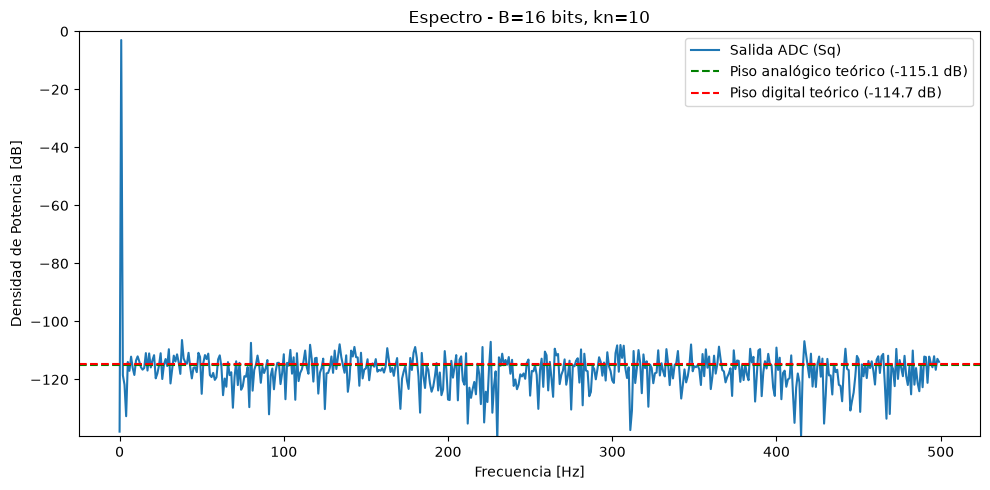

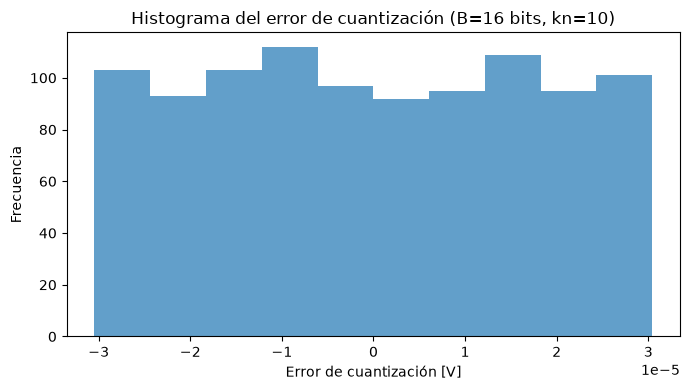

In [34]:
simular(B=16, kn=0.1)
simular(B=16, kn=1)
simular(B=16, kn=10)

Al llevar la resolución a $B = 16$ bits ($65.536$ niveles de cuantización), el paso de cuantización se vuelve ínfimo: $q = \frac{4}{65536} \approx 61\ \mu\text{V}$ ($0,061\text{ mV}$). Esto hace que la potencia de cuantización caiga a niveles del orden de los picowatios ($P_q \approx 310,4\text{ pW}$).
Dominio del tiempo: Para $k_n = 0,1$ y $k_n = 1$: La señal digitalizada es visualmente idéntica a una onda analógica continua y perfecta. Los escalones de $61\ \mu\text{V}$ son totalmente invisibles a la escala del gráfico de volts. En ambos casos, el trazo de la senoidal se ve suave, firme y sin ninguna imperfección apreciable. Para $k_n = 10$: La señal muestra una ligera rugosidad en el trazo, pero esto se debe exclusivamente al ruido analógico de entrada que proviene del canal ($P_n = 10 P_q \approx 3,1\text{ nW}$), el cual supera por un orden de magnitud al minúsculo escalón del ADC. La estructura escalonada del convertidor se perdio.
Dominio de la frecuencia (Espectro):
Al agregar 8 bits adicionales de resolución respecto al caso de 8 bits (y 12 bits respecto al de 4 bits), la potencia del ruido de cuantización disminuye drásticamente, desplazando todo el bloque del espectro aproximadamente $48\text{ dB}$ más hacia abajo que en 8 bits (y $72\text{ dB}$ más abajo que en 4 bits). El piso de ruido queda ubicado en el fondo del espectro (cerca de los $-98\text{ dB}$ teóricos). Las relaciones de potencia en decibeles entre el piso analógico y el digital se mantienen matemáticamente idénticas a los casos anteriores:Con $k_n = 0,1$, el piso digital se ubica $10\text{ dB}$ por encima del analógico.Con $k_n = 1$, la suma de potencias iguales eleva el piso en $3\text{ dB}$.Con $k_n = 10$, los pisos analógico y digital quedan superpuestos. 

#### Conclusion
En esta tarea semanal simulamos de forma completa el funcionamiento de un ADC real, integrando tanto el muestreo en el tiempo ($f_s = 1000\text{ Hz}$) como la cuantización en amplitud ($B$ bits) sobre una senoidal contaminada con ruido analógico ($k_n$). A partir de los experimentos y el análisis de los gráficos, llegamos a las siguientes conclusiones principales:
El balance entre $B$ y $k_n$ define el rendimiento: La calidad de la señal digitalizada (SNR) no depende únicamente de cuántos bits tenga el ADC, sino de la relación entre el ruido de cuantización propio del convertidor ($P_q$) y el ruido analógico que viene de afuera ($P_n$).
Sistemas limitados por cuantización ($k_n = 0.1$): Si el ruido externo es casi nulo, el único límite es el propio ADC. En este caso, aumentar los bits (de 4 a 8 y 16) se aprovecha al máximo: el piso de ruido en el espectro cae fuertemente ($-24\text{ dB}$ de 4 a 8 bits y $-48\text{ dB}$ más en 16 bits) y la señal en el tiempo se suaviza hasta volver los escalones invisibles.
Sistema balanceado ($k_n = 1$): Ambas fuentes de ruido, la de cuantización y la analógica, aportan la misma potencia. Aumentar la cantidad de bits ($B$) sigue mejorando el rendimiento, pero el ritmo de ganancia disminuye progresivamente. Esto ocurre porque, aunque se reduzca $P_q$ al elevar la resolución del ADC, la potencia de ruido analógico $P_n$ se mantiene constante, actuando como una cota inferior que restringe el incremento máximo del SNR total.
Relación de pisos en dB: Se confirmó experimentalmente que la distancia entre el piso analógico y el de cuantización depende solo del factor $k_n$, según $-10\log_{10}(k_n)$:En $k_n = 0.1$, el piso de cuantización queda $10\text{ dB}$ por encima del analógico (el ADC es el limitante).En $k_n = 1$, ambos pisos se superponen (sin diferencia entre ellos).En $k_n = 10$, el piso analógico queda $10\text{ dB}$ por encima del de cuantización (el canal es el limitante).
Costo en SNR: En términos de degradación del SNR total respecto del caso ideal ($-10\log_{10}(k_n + 1)$), el impacto va de: Casi despreciable en $k_n = 0.1$ ($-0.41\text{ dB}$). Significativo en $k_n = 1$ ($-3.01\text{ dB}$, equivalente a perder medio bit de resolución). Severo en $k_n = 10$ ($-10.41\text{ dB}$, equivalente a perder casi 2 bits de resolución efectiva).